<a href="https://colab.research.google.com/github/etebongibekwe-stack/Beam-shaping/blob/main/Neural_network24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [568]:
## imort all libraries

In [569]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [570]:
## craete a nueral network class that inherit neural network properties

In [571]:
class Model(nn.Module):
    def __init__(self,input_features =4, h1 = 8, h2 = 9, output = 3):
      super().__init__()
      self.f1 = nn.Linear(input_features,h1)
      self.f2 = nn.Linear(h1,h2)
      self.out = nn.Linear(h2,output)
    def forward(self,x):
        x = F.relu(self.f1(x))
        x = F.relu(self.f2(x))
        x = self.out(x)
        return x

In [572]:
## create a manual seed for randomization

In [573]:
torch.manual_seed(40)

In [574]:
model = Model()

In [575]:
## load our data

In [576]:
url = 'https://raw.githubusercontent.com/amankharwal/Website-data/master/IRIS.csv'
df = pd.read_csv(url)



In [577]:
## convert categorical data to float


In [578]:
df['species'] = df['species'].astype('category')
df['species'] = df['species'].cat.codes


In [579]:
## split the data into observation and target


In [580]:
x= df.drop('species', axis=1)

In [581]:
y=df.species

In [582]:
## split test train

In [583]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

In [584]:
## convert data to numpy array

In [585]:
x_train = x_train.values
x_test = x_test.values
y_train = y_train.values
y_test = y_test.values

In [586]:
## convert numpy array to tensor

In [587]:
x_test = torch.tensor(x_test).float()
x_train = torch.tensor(x_train).float()
y_test = torch.LongTensor(y_test)
y_train = torch.LongTensor(y_train)

In [588]:
## set the criterion of the model to measure the error

In [589]:
criterion = nn.CrossEntropyLoss()

In [590]:
## set the optimizer and learning rate

In [591]:
optimzer = torch.optim.Adam(model.parameters(), lr=0.01)

In [592]:
## train the model

In [593]:
epochs = 150
losses = []
for i in range(epochs):
  y_pred = model.forward(x_train)
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())


  if i%10==0:
    print(f'epoch: {i:2}  loss: {loss.item():10.8f}')
  ## back propagation take the error rate of foward propagation
  ## and feed it back to the model
  optimzer.zero_grad()
  loss.backward()
  optimzer.step()

epoch:  0  loss: 1.15033925
epoch: 10  loss: 1.09397459
epoch: 20  loss: 1.07274234
epoch: 30  loss: 0.99765611
epoch: 40  loss: 0.81227726
epoch: 50  loss: 0.59622502
epoch: 60  loss: 0.46060741
epoch: 70  loss: 0.39134401
epoch: 80  loss: 0.33207652
epoch: 90  loss: 0.24333832
epoch: 100  loss: 0.15216155
epoch: 110  loss: 0.09919216
epoch: 120  loss: 0.07621191
epoch: 130  loss: 0.06589942
epoch: 140  loss: 0.06073673


In [594]:
## plot the losses

Text(0.5, 0, 'epoch')

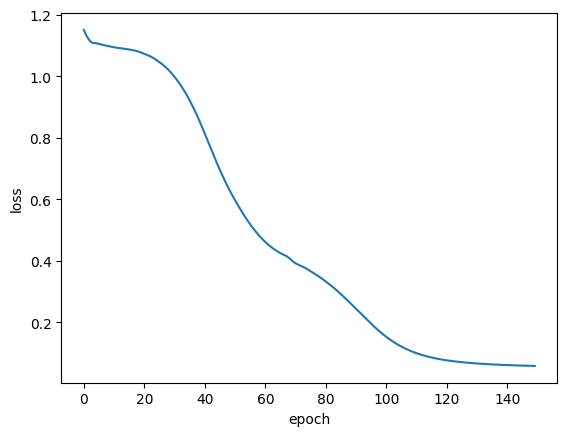

In [595]:
plt.plot(range(epochs), losses)
plt.ylabel('loss')
plt.xlabel('epoch')
#

In [596]:
## validating the dataset using the test data

In [597]:
with torch.no_grad(): ## we off the back propagation
  y_eval = model.forward(x_test)
  loss = criterion(y_eval, y_test)

In [598]:
## the loss to compare with the trainnig loss

In [599]:
loss , losses[-1] ## test loss compare to last train loss

(tensor(0.0489), array(0.05807861, dtype=float32))

In [600]:
## check the data that are predicted correctly
## by taking each data pass through the model

In [601]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(x_test):
    y_val = model(data)
    print(f'{i+1:2}. {str(data.numpy()):20}\t {y_val.argmax().item()} \t {y_test[i]}')
    if y_val.argmax().item() == y_test[i]:
      correct += 1
print(f'\n{correct} out of {len(y_test)}')

 1. [4.4 3.  1.3 0.2]   	 0 	 0
 2. [5.6 3.  4.5 1.5]   	 1 	 1
 3. [6.4 3.2 5.3 2.3]   	 2 	 2
 4. [7.7 3.8 6.7 2.2]   	 2 	 2
 5. [5.5 2.5 4.  1.3]   	 1 	 1
 6. [6.3 3.4 5.6 2.4]   	 2 	 2
 7. [6.2 2.2 4.5 1.5]   	 1 	 1
 8. [5.6 2.7 4.2 1.3]   	 1 	 1
 9. [5.4 3.  4.5 1.5]   	 1 	 1
10. [5.2 3.4 1.4 0.2]   	 0 	 0
11. [5.5 2.6 4.4 1.2]   	 1 	 1
12. [4.8 3.4 1.6 0.2]   	 0 	 0
13. [5.  3.5 1.3 0.3]   	 0 	 0
14. [6.2 2.8 4.8 1.8]   	 2 	 2
15. [5.7 2.6 3.5 1. ]   	 1 	 1
16. [6.7 3.3 5.7 2.5]   	 2 	 2
17. [6.3 2.7 4.9 1.8]   	 2 	 2
18. [6.7 3.3 5.7 2.1]   	 2 	 2
19. [6.8 2.8 4.8 1.4]   	 1 	 1
20. [5.2 2.7 3.9 1.4]   	 1 	 1
21. [6.4 2.8 5.6 2.2]   	 2 	 2
22. [7.6 3.  6.6 2.1]   	 2 	 2
23. [5.5 2.3 4.  1.3]   	 1 	 1
24. [5.1 3.5 1.4 0.3]   	 0 	 0
25. [5.6 2.9 3.6 1.3]   	 1 	 1
26. [5.7 3.8 1.7 0.3]   	 0 	 0
27. [4.3 3.  1.1 0.1]   	 0 	 0
28. [6.5 3.  5.5 1.8]   	 2 	 2
29. [4.9 3.1 1.5 0.1]   	 0 	 0
30. [5.5 2.4 3.7 1. ]   	 1 	 1

30 out of 30
